In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/historical-gold-prices-19952026/gold_prices_1995_2026_feb.csv


0.3215877142791285


,Date,Gold_Price_USD_YFinance
302,2025-10-01,4044.373907
303,2025-11-01,4082.115761
304,2025-12-01,4311.059104
305,2026-01-01,4730.859961
306,2026-02-01,4815.533366


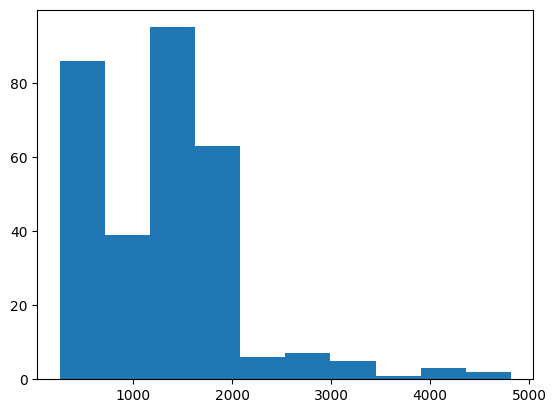

In [39]:
import numpy as np
Data=pd.read_csv('/kaggle/input/historical-gold-prices-19952026/gold_prices_1995_2026_feb.csv')

data=Data.Gold_Price_USD_YFinance.values
plt.hist(data)
data,param=scipy.stats.boxcox(data)
print(param)
Data.tail()

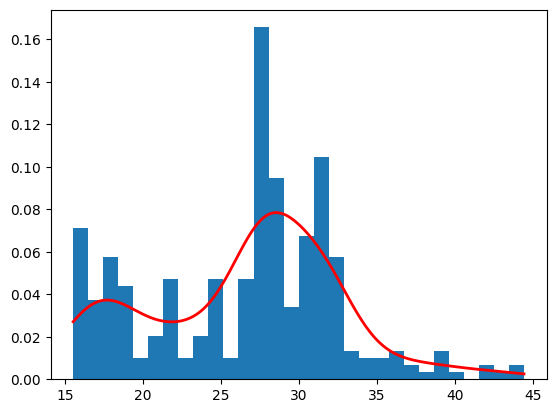

In [40]:
import matplotlib.pyplot as plt
import scipy
plt.hist(data,density=True,bins=30)
kde = scipy.stats.gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 200)
plt.plot(x_range, kde(x_range), 'r-', linewidth=2)

In [56]:
import torch
from torch import nn
class Datas(torch.utils.data.Dataset):
    def __init__(self,data,prev):
        super().__init__()
        self.data=torch.tensor(data,dtype=torch.float64)
        self.prev=prev
    def __getitem__(self,id):
        return self.data[id:id+self.prev].unsqueeze(1),self.data[id+self.prev:id+self.prev+1]
    def __len__(self):
        return len(self.data)-self.prev

Dat=Datas(data,15)
Load=torch.utils.data.DataLoader(Dat,shuffle=True,batch_size=20)
class Model(nn.Module):
    def __init__(self,h=10):
        super().__init__()
        self.l1=nn.LSTM(1,h,batch_first=True)
        self.l2=nn.Linear(h,1)
    def forward(self,x):
        x,h=self.l1(x)
        x=self.l2(h[0].squeeze())
        return x
model=Model()

In [57]:
N_epoch=100
loss_func=torch.nn.MSELoss()
opt=torch.optim.NAdam(model.parameters(),lr=0.01)

model.train()
for _ in range(N_epoch):
    for x,y in Load:
        x=x.float()
        y=y.float()
        pred=model(x)
        Loss=loss_func(pred,y)
        opt.zero_grad()
        Loss.backward()
        opt.step()

In [62]:
Q=0.0
for i in range(len(Dat)):
    x,y=Dat[i]
    pred=model(x.float())
    Q+=loss_func(pred,y.float())
Q/=len(Dat)
print(Q.item(),np.std(data)**2)


1.2485283613204956 38.021451487492385
